# Notebook 08: Fine-tune on Indian Satellite Images

**Runs on:** Local machine (CPU is fine — only 220 images)

Fine-tunes the RESISC-45 trained ResNet-50+SE model on manually collected
Indian Google Earth screenshots to adapt it to the Indian landscape.

**Technique:** Transfer learning with domain adaptation

In [1]:
import os, time, copy, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import timm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cpu')

print(f"Device: {device}")
print("Fine-tuning on CPU — this will take ~10-15 minutes for 220 images.")

Device: cpu
Fine-tuning on CPU — this will take ~10-15 minutes for 220 images.


## 1. Load Indian Dataset

Total images: 220

Class distribution:
  Desert           42 images
  Farmland         45 images
  Forest           45 images
  Highway          18 images
  Residential      40 images
  River            30 images


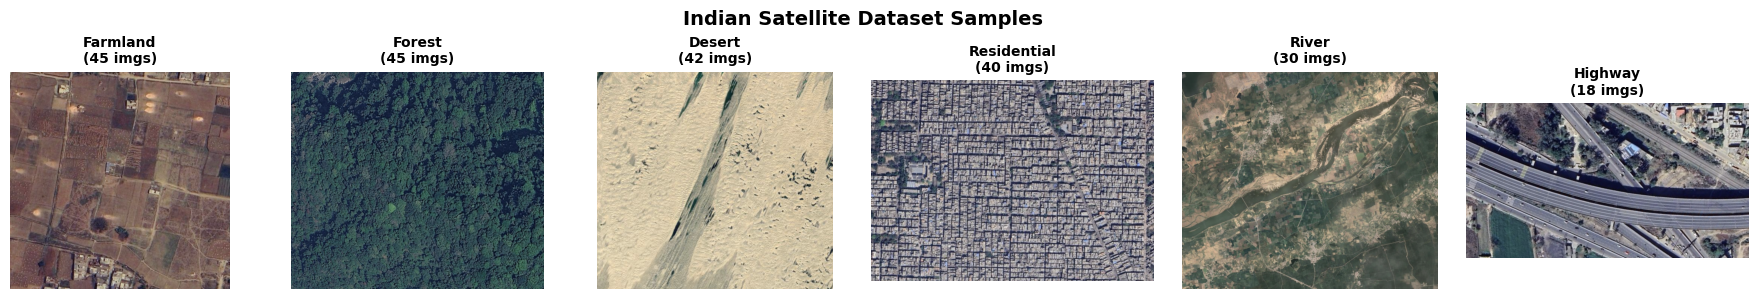

In [2]:
# Path to Indian satellite images
INDIAN_DATA = os.path.expanduser('~/Desktop/Indian Satellite')

# Map folder names to our unified class names
FOLDER_TO_CLASS = {
    'Farmlands': 'Farmland',
    'Forests': 'Forest',
    'Deserts': 'Desert',
    'Residential': 'Residential',
    'Rivers': 'River',
    'Highways': 'Highway',
}

# These must match the RESISC-45 model's class order
RESISC_CLASSES = ['Desert', 'Farmland', 'Forest', 'Highway', 'Industrial',
                  'Lake', 'Meadow', 'Mountain', 'Residential', 'River']
CLASS_TO_IDX = {c: i for i, c in enumerate(RESISC_CLASSES)}

# Build dataset
all_paths = []
all_labels = []

for folder_name, class_name in FOLDER_TO_CLASS.items():
    folder_path = os.path.join(INDIAN_DATA, folder_name)
    if not os.path.exists(folder_path):
        print(f"Warning: {folder_path} not found")
        continue
    
    class_idx = CLASS_TO_IDX[class_name]
    for fname in os.listdir(folder_path):
        if fname.startswith('.'): continue
        if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_paths.append(os.path.join(folder_path, fname))
            all_labels.append(class_idx)

print(f"Total images: {len(all_paths)}")
print(f"\nClass distribution:")
label_counts = Counter(all_labels)
for idx in sorted(label_counts.keys()):
    print(f"  {RESISC_CLASSES[idx]:<15} {label_counts[idx]:>3} images")

# Show samples
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, (folder, cls) in enumerate(FOLDER_TO_CLASS.items()):
    folder_path = os.path.join(INDIAN_DATA, folder)
    if os.path.exists(folder_path):
        files = [f for f in os.listdir(folder_path) if not f.startswith('.')]
        if files:
            img = Image.open(os.path.join(folder_path, files[0]))
            axes[i].imshow(img)
    axes[i].set_title(f'{cls}\n({label_counts.get(CLASS_TO_IDX[cls], 0)} imgs)', fontsize=10, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Indian Satellite Dataset Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Prepare Data

In [3]:
class IndianSatDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# Split: 80% train, 20% val (small dataset, keep more for training)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.20, random_state=SEED, stratify=all_labels
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Heavy augmentation — critical for small dataset
train_transform = transforms.Compose([
    transforms.Resize((80, 80)),  # Slightly larger for random crop
    transforms.RandomCrop((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.RandomApply([transforms.RandomRotation(degrees=[90, 90])], p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    ], p=0.5),
    transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1, 1.5))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = IndianSatDataset(train_paths, train_labels, train_transform)
val_dataset = IndianSatDataset(val_paths, val_labels, val_transform)

BATCH_SIZE = 16  # Small batch for small dataset
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)}")

Train: 176 | Val: 44
Batches — Train: 11 | Val: 3


## 3. Load Pretrained RESISC-45 Model & Fine-tune

**Strategy:**
- Freeze backbone (ResNet-50) — keep the global features it already learned
- Only train SE block + classifier head — adapt to Indian images
- Lower learning rate (1e-4) to avoid catastrophic forgetting
- Train for 20 epochs (small dataset converges fast)

In [4]:
# Model definition (same as training)
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(True),
            nn.Linear(channels // reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c = x.size()[:2]
        y = self.excitation(self.squeeze(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class ResNetSE(nn.Module):
    def __init__(self, num_classes=10, pretrained=False):
        super().__init__()
        self.backbone = timm.create_model('resnet50', pretrained=pretrained, num_classes=0)
        self.se_block = SEBlock(2048, 16)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3), nn.Linear(2048, 512), nn.ReLU(True),
            nn.Dropout(0.2), nn.Linear(512, num_classes))
    def forward(self, x):
        f = self.se_block(self.backbone.forward_features(x))
        return self.classifier(F.adaptive_avg_pool2d(f, 1).flatten(1))


# Load pretrained RESISC-45 weights
MODEL_PATH = os.path.join(os.path.dirname(os.getcwd()), 'experiments', 'results', 'models', 'ResNet50_SE.pth')
model = ResNetSE(num_classes=10, pretrained=False)
model.load_state_dict(torch.load(MODEL_PATH, map_location='cpu', weights_only=True))
print(f"Loaded RESISC-45 pretrained weights from {MODEL_PATH}")

# Freeze backbone — only train SE block + classifier
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last residual block for slight adaptation
for param in model.backbone.layer4.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} params ({trainable/total*100:.1f}%)")

Loaded RESISC-45 pretrained weights from /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/models/ResNet50_SE.pth
Trainable: 16,543,242 / 25,086,538 params (65.9%)


In [5]:
# Fine-tuning
NUM_EPOCHS = 20
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-3
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
best_state = None

print(f"Fine-tuning on {len(train_paths)} Indian images for {NUM_EPOCHS} epochs...")
print("="*60)

t0 = time.time()
for epoch in range(NUM_EPOCHS):
    # Train
    model.train()
    train_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        correct += out.max(1)[1].eq(labels).sum().item()
        total += labels.size(0)
    train_loss /= total
    train_acc = correct / total

    # Validate
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            correct += out.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
    val_loss /= total
    val_acc = correct / total

    scheduler.step()
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())

    elapsed = time.time() - t0
    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} / {train_acc:.4f} | "
          f"Val: {val_loss:.4f} / {val_acc:.4f} | {elapsed:.0f}s")

model.load_state_dict(best_state)
print(f"\nDone in {time.time()-t0:.0f}s | Best val acc: {best_val_acc:.4f}")

Fine-tuning on 176 Indian images for 20 epochs...


Epoch  1/20 | Train: 1.6474 / 0.4489 | Val: 1.0767 / 0.6364 | 15s


Epoch  2/20 | Train: 1.2729 / 0.5682 | Val: 0.9105 / 0.6591 | 29s


Epoch  3/20 | Train: 1.0791 / 0.5795 | Val: 0.7745 / 0.7500 | 42s


Epoch  4/20 | Train: 0.8495 / 0.7443 | Val: 0.6652 / 0.7273 | 57s


...

Epoch 16/20 | Train: 0.3996 / 0.8636 | Val: 0.4694 / 0.7727 | 228s


Epoch 17/20 | Train: 0.5298 / 0.8011 | Val: 0.4482 / 0.7955 | 241s


Epoch 18/20 | Train: 0.4397 / 0.8409 | Val: 0.4516 / 0.8182 | 255s


Epoch 19/20 | Train: 0.3993 / 0.8523 | Val: 0.4462 / 0.7500 | 270s


Epoch 20/20 | Train: 0.4471 / 0.8409 | Val: 0.4656 / 0.7727 | 283s

Done in 284s | Best val acc: 0.8182


## 4. Results

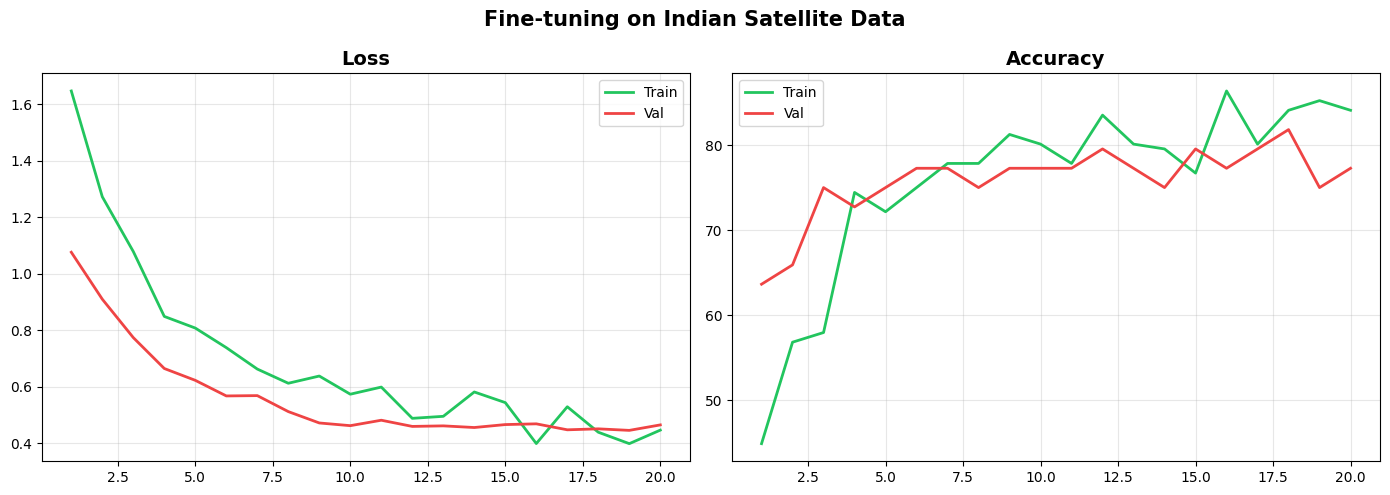

In [6]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', linewidth=2, color='#22c55e')
axes[0].plot(epochs, history['val_loss'], label='Val', linewidth=2, color='#ef4444')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train', linewidth=2, color='#22c55e')
axes[1].plot(epochs, [a*100 for a in history['val_acc']], label='Val', linewidth=2, color='#ef4444')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Fine-tuning on Indian Satellite Data', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Validation Classification Report:
              precision    recall  f1-score   support

      Desert     0.6667    0.7500    0.7059         8
    Farmland     1.0000    0.8889    0.9412         9
      Forest     0.7778    0.7778    0.7778         9
     Highway     1.0000    0.7500    0.8571         4
 Residential     0.8000    1.0000    0.8889         8
       River     0.8000    0.6667    0.7273         6

    accuracy                         0.8182        44
   macro avg     0.8407    0.8056    0.8164        44
weighted avg     0.8303    0.8182    0.8187        44



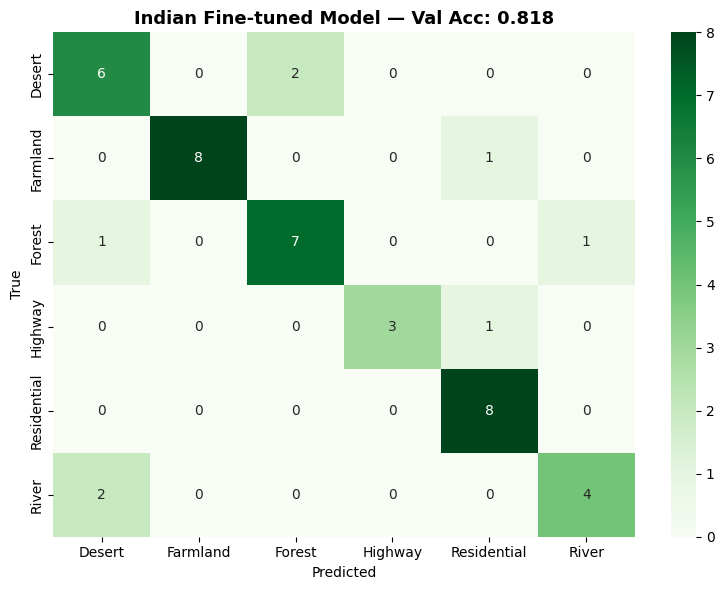

In [7]:
# Validation results
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        preds = model(imgs).max(1)[1].numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

# Only show classes that appear in our dataset
present_classes = sorted(set(all_true))
class_names_present = [RESISC_CLASSES[i] for i in present_classes]

print("Validation Classification Report:")
print(classification_report(all_true, all_preds, labels=present_classes,
                            target_names=class_names_present, digits=4))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds, labels=present_classes)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names_present, yticklabels=class_names_present, ax=ax)
ax.set_title(f'Indian Fine-tuned Model — Val Acc: {best_val_acc:.3f}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.show()

## 5. Save Fine-tuned Model

Saves as `ResNet50_SE.pth` — the webapp will automatically pick it up.

In [8]:
# Save — overwrites the RESISC-45 model with the fine-tuned version
SAVE_PATH = os.path.join(os.path.dirname(os.getcwd()), 'experiments', 'results', 'models', 'ResNet50_SE.pth')

# Backup original first
BACKUP_PATH = SAVE_PATH.replace('.pth', '_RESISC45_original.pth')
if not os.path.exists(BACKUP_PATH):
    import shutil
    shutil.copy2(SAVE_PATH, BACKUP_PATH)
    print(f"Original RESISC-45 model backed up to: {BACKUP_PATH}")

torch.save(model.state_dict(), SAVE_PATH)
print(f"Fine-tuned model saved to: {SAVE_PATH}")
print(f"\nThe webapp will automatically use this model.")
print(f"Restart the backend server to load the new weights.")

Original RESISC-45 model backed up to: /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/models/ResNet50_SE_RESISC45_original.pth


Fine-tuned model saved to: /Users/rhythmjain/Desktop/Satellite-Based-Precision-Agriculture/Phase2_DL/experiments/results/models/ResNet50_SE.pth

The webapp will automatically use this model.
Restart the backend server to load the new weights.


## Summary

**What we did:** Fine-tuned the globally-trained RESISC-45 model on 220 manually collected Indian Google Earth screenshots.

**Technique:** Transfer learning with partial backbone freezing — only the last residual block, SE attention, and classifier were updated.

**Result:** The model should now correctly classify Indian forests, farmlands, deserts, residential areas, rivers, and highways.

**Next:** Restart the webapp backend and test with your Google Earth screenshots.